# Comparing WGCNA modules across phases
Through WGCNA, I identified significantly correlated modules with treatments/growth in both phase 1 and phase 2 oysters. In this notebook, I want to dig deeper into the identified modules and see if there are overlapping genes between similarly correlated modules in phase 1 and 2 oysters.

## 0. load libraries

In [3]:
library(tidyverse)
library(RColorBrewer)
library(rtracklayer)

## 1. read CSVs
these module outputs come from the [phase 1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/newRef_wgcna_p1.ipynb) and [phase 2](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/wgcna/prefilter_newRef_wgcna_p2.ipynb) WGCNA analyses.

#### phase 1 oysters 

In [5]:
p1_geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_GeneInfo.csv')
head(p1_geneInfo)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.282186775,0.06994163,0.1492213,0.385003047,-0.02872849,0.12634487,⋯,0.3336787,0.09526861,-0.03750345,-0.01178295,-0.04856269,0.115416013,-0.46324802,-0.19648759,0.05033161,-0.04085780
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,black,-0.02461599,0.002751307,-0.03894892,-0.4217885,-0.363072643,-0.28138410,-0.24659525,⋯,-0.2452065,-0.14257739,-0.16774119,0.34293007,0.31439017,-0.065239565,0.07719106,-0.15380042,0.22565913,0.02356195
3,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.303838275,-0.01706141,-0.2141764,0.221972568,-0.34604876,-0.04315846,⋯,0.1248501,0.26055230,0.01693705,0.20241978,0.34095291,0.002859469,-0.37935688,-0.49934818,0.05801009,-0.35374473
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.41098524,-0.310348052,-0.04403876,0.3171945,0.004370064,0.34594159,0.31502257,⋯,-0.4530072,-0.51091263,-0.31182848,-0.07876548,0.07063991,0.365824475,0.50638260,0.32368892,0.40288267,0.68022795
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,green,-0.35176148,-0.282846525,-0.03894228,-0.0592647,-0.254057873,0.06198487,-0.01882029,⋯,-0.3888532,-0.68292735,-0.49529157,0.14867298,0.47087567,-0.253669949,0.40577513,0.03737518,0.72387889,0.49103455
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.181368789,-0.15299170,-0.3250255,0.370840965,-0.54214175,-0.10090793,⋯,0.7387194,0.17197754,0.25907960,0.07602426,-0.20551234,-0.602026100,-0.33485347,-0.05929480,-0.20905792,-0.29068175


#### phase 2 oysters

In [6]:
p2_geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_GeneInfo.csv')
head(p2_geneInfo)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,⋯,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,green,0.14571142,0.05937969,-0.109564792,-0.12499754,-0.01985215,-0.128608602,-0.05370241,⋯,0.009638715,0.14857330,0.150462603,0.0014763335,0.10330871,0.20884429,0.07217231,-0.058705838,-0.063588526,-0.168151337
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,black,0.02275339,-0.06710301,-0.113811162,0.01333703,0.03823132,-0.004338504,0.15336122,⋯,0.134078073,-0.12596425,-0.169428680,0.0001014633,-0.07418067,0.04122113,-0.07353120,-0.008073588,0.075545608,0.009819899
3,LOC111099040,GO:0005515;GO:0007169;GO:0035556,black,-0.02129411,-0.03599048,-0.009529534,0.19284124,0.10132621,0.163054335,0.15998130,⋯,0.209695014,0.07264407,-0.093507897,-0.1093702268,-0.03710835,0.24539274,0.12959445,-0.109145432,-0.007852902,-0.065906431
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,black,-0.04812120,-0.10076555,-0.011929654,0.12670143,0.14377818,0.068519391,0.35017609,⋯,0.045893617,0.01785133,0.074087246,0.2533965011,0.19857920,0.46199620,0.11825447,0.009861154,0.276834705,-0.247062909
5,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,green,-0.05057534,-0.03567957,-0.078227407,0.02812682,0.12377098,-0.030726663,0.16142128,⋯,0.099713237,-0.01010121,-0.061427955,-0.0005536777,0.16424719,0.45477782,0.17354495,0.095553785,0.018403605,-0.155316540
6,LOC111099048,GO:0000302;GO:0005737;GO:0006629;GO:0031409,yellow,-0.03194334,-0.17166732,-0.142415748,0.01994378,-0.05197196,0.048096172,-0.04022407,⋯,-0.127597289,0.01079934,-0.006241344,-0.0653833675,0.07945784,0.03267339,-0.01281366,0.108991599,0.054429507,-0.021963826


## 2. compare modules

In phase 1 oysters, there are only 3 significant modules:
- red, which is negatively correlated with tissue growth
- blue, which is positively correlateed with shell growth and the warm treatment
- black, which negatively correlated with temperature

I think the easiest way to compare modules is to pull out the matching genes for the phase 1 modules, and see if they're coming from the same module in phase 2


### phase 1 red module

In [8]:
p1red <- p1_geneInfo %>% filter(ModuleColor == 'red')
dim(p1red)
head(p1red)

p1red.geneList <- p1red %>% pull(Gene)
head(p1red.geneList)

[1] 714  34

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.41098524,-0.31034805,-0.04403876,0.31719449,0.004370064,0.34594159,0.315022568,⋯,-0.45300723,-0.5109126,-0.3118285,-0.07876548,0.07063991,0.36582448,0.5063826,0.3236889,0.4028827,0.6802280
2,LOC111099693,GO:0003713;GO:0042800;GO:0044666;GO:0045944,red,-0.40472129,-0.21510355,0.07624957,0.27614768,0.133768594,0.23619272,0.184311916,⋯,-0.31462488,-0.7529479,-0.4508056,-0.51306302,0.08572571,0.07119193,0.4887200,0.3557724,0.7204733,0.8257951
3,LOC111099735,GO:0016192;GO:0046872;GO:0071782;GO:0071787;GO:0072659,red,0.01973772,0.15863297,0.24399899,0.08599462,-0.007219988,0.09799063,0.110865878,⋯,-0.30797509,-0.4606492,-0.1071672,-0.39091269,-0.01699828,0.43312495,0.5656473,0.4018363,0.3709339,0.4719244
4,LOC111099746,GO:0005524;GO:0016020;GO:0016887;GO:0055085;GO:0140359,red,-0.13193244,-0.06459774,0.03766456,0.11703581,0.072317328,0.09229022,0.110106311,⋯,-0.19314713,-0.8203041,-0.5346497,-0.19434305,0.19222201,-0.03246489,0.3296064,0.2200731,0.8200251,0.7850884
5,LOC111099748,GO:0005524;GO:0016020;GO:0016887;GO:0055085;GO:0140359,red,0.12584809,0.17526897,0.13254837,-0.02414464,0.015087173,-0.03404276,0.001331461,⋯,-0.07628865,-0.6263643,-0.2661227,-0.31150067,-0.01546547,-0.02108352,0.3775180,0.3486656,0.5265380,0.5888553
6,LOC111099814,GO:0003677;GO:0006310;GO:0015074,red,-0.01134809,0.14115925,0.21767435,-0.12643038,0.132882244,-0.20520073,-0.143742022,⋯,-0.04431040,-0.3213722,-0.2295507,-0.32752582,-0.02938513,-0.09819086,0.1399721,0.1696643,0.2970881,0.3547488


[1] "LOC111099041" "LOC111099693" "LOC111099735" "LOC111099746" "LOC111099748"
[6] "LOC111099814"

now looking for overlap in phase 2 oysters

In [ ]:
p1_inRed <- p2_geneInfo[p2_geneInfo$Gene %in% p1red.geneList, ] %>% 
group_by(ModuleColor) %>%
count()

head(p1_inRed)

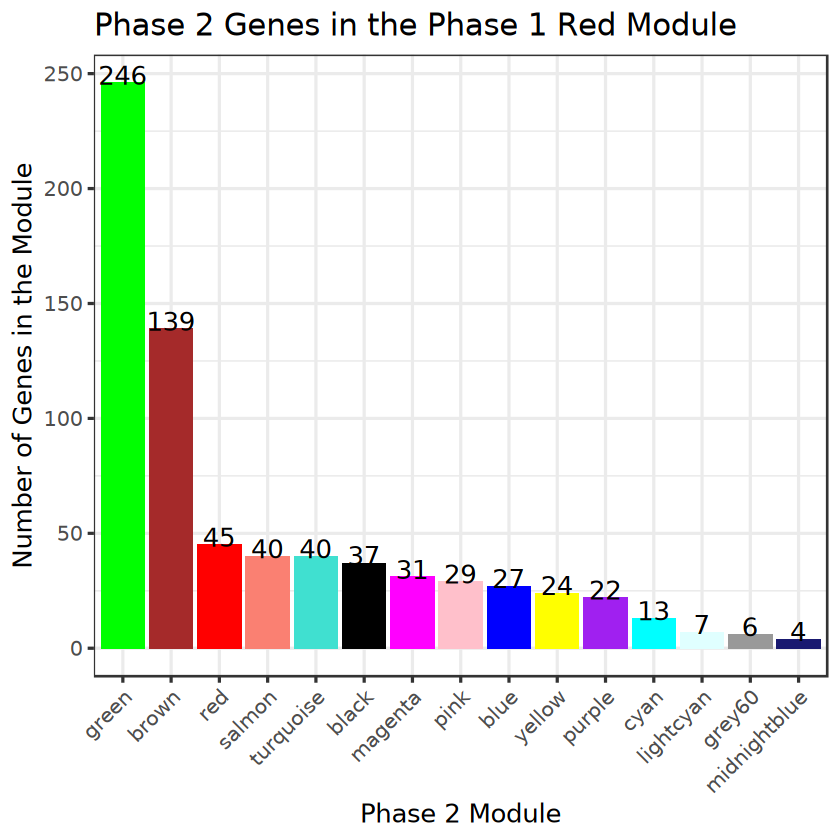

In [23]:
ggplot(p1_inRed, aes(x = fct_infreq(ModuleColor), fill = ModuleColor)) +
geom_bar() + 
geom_text(
    stat = "count", 
    aes(label = after_stat(count)),
    vjust = 0.1
  ) +
theme_bw(base_size = 15) +
theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
scale_fill_identity() +
labs(x = 'Phase 2 Module',
     y = 'Number of Genes in the Module',
     title = 'Phase 2 Genes in the Phase 1 Red Module')

so for the phase 1 module, the majority of genes are assigned to the green and brown modules in phase 2 oysters

in phase 2 modules:
- green is negatively correlated with late control and positively correlated with late warm and hypoxic
- brown is positively correlated with late hypoxic and negatively correlated with late both

as a reminder, this phase 1 red module is negatively correlated with tissue growth (increased tissue growth is associated with lower expression)

not just what to make of this? i'm wondering if the genes that overlap are part of the group that have high correlation with tissue growth or if they are more "on the fringe" of that module. Would be interested to look closer at the phase 2 growth - do similar patterns emerge in phase 2 as in phase 1? if there are not strong differences in growth for phase 2 oysters, that could explain why we don't see a correlation for growth. But I'm still confused how these genes could contribute to growth early on and then "switch" later ... so what else are they doing and/or contributing to oyster resilience?